## Library import

In [ ]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 26.8 MB/s eta 0:00:00


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import opensmile
import joblib
from tensorflow.keras.applications import ResNet50

# Scikit-learn imports
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from scipy.signal import butter, lfilter
from tqdm.auto import tqdm

# Mount Google Drive
from google.colab import drive

## Data Collection

In [ ]:
#เชื่อม Drive ตัวเอง
drive.mount('/content/drive')


# Set your base path in Google Drive เชื่อม path ที่วางข้อมูลไว้
base_path = "/content/drive/MyDrive/SoundDe/"

#หา folder ที่วางข้อมูลทั้ง 2 class
dementia_folder = os.path.join(base_path, "dementia dataset balance")
nodementia_folder = os.path.join(base_path, "nodementia dataset")


Mounted at /content/drive


In [ ]:
nodementia_folder

'/content/drive/MyDrive/SoundDe/nodementia dataset'

In [ ]:
# Get list of audio files ทำเป็น list เสียงของทั้ง 2 class
dementia_files = [os.path.join(dementia_folder, f) for f in os.listdir(dementia_folder) if f.endswith(".wav")]
nodementia_files = [os.path.join(nodementia_folder, f) for f in os.listdir(nodementia_folder) if f.endswith(".wav")]

In [ ]:
dementia_files

['/content/drive/MyDrive/SoundDe/dementia dataset balance/Jessejackson_0.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/PeterFalk_10.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/emilegriffith_5.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/johnmackey_15_2.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/andrewsachs_10.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/JamesStewart_5.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/johnmackey_15_1.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/terryjones_5.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/DavidProwse_0.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/TimConway_5.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/alanramsey_10.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/PeterFalk_15.wav',
 '/content/drive/MyDrive/SoundDe/dementia dataset balance/ma

In [ ]:
# รวม paths ไฟล์และสร้างlabels(1 สำหรับภาวะสมองเสื่อม, 0 สำหรับไม่มีภาวะสมองเสื่อม)
file_paths = dementia_files + nodementia_files
labels = [1] * len(dementia_files) + [0] * len(nodementia_files)

print(f"Total dementia files: {len(dementia_files)}")
print(f"Total non-dementia files: {len(nodementia_files)}")
print(f"Total files: {len(file_paths)}")

# สร้าง Dictionary เพื่อเก็บผลลัพธ์ของแต่ละโมเดล
performance_summary = {}

Total dementia files: 96
Total non-dementia files: 96
Total files: 192


## Data preprocessing

In [ ]:
# Preprocessing Functions ที่จำเป็น

# กรองความถี่
def butter_bandpass(lowcut, highcut, fs, order=5):
    """Creates a band-pass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(y, sr, lowcut=80, highcut=8000):
    """Applies the band-pass filter to the audio signal."""
    b, a = butter_bandpass(lowcut, highcut, sr, order=5)
    y_filtered = lfilter(b, a, y)
    return y_filtered

# เปลี่ยนเสียงให้อยู่ในรูปแบบ mel Spectrogram นิยมใช้ในงานแยกประเภทเสียง
def extract_mel_spectrograms(y, sr, segment_length_sec=10, hop_length_sec=5, n_mels=128):
    """
    Extracts Mel Spectrograms from an audio signal using a sliding window.
    """
    segment_samples = segment_length_sec * sr
    hop_samples = hop_length_sec * sr

    spectrograms = []

    # Pad the audio if it's shorter than one segment
    if len(y) < segment_samples:
        padding = segment_samples - len(y)
        y = np.pad(y, (0, padding), mode='constant')

    # Create segments using a sliding window
    for i in range(0, len(y) - segment_samples + 1, hop_samples):
        segment = y[i:i + segment_samples]

        # Calculate Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        spectrograms.append(mel_spec_db)

    return spectrograms

In [ ]:
# Function สำหรับทำกราฟดูประสิทธิภาพ
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    fig.suptitle(f'{model_name} - Training History', fontsize=16)
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_ylabel('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

In [ ]:
# Data Loading and Processing
X_spec_list = []
y_spec_list  = []
SR = 22050 # อัตราการสุ่มตัวอย่าง

#เป็นขั้นตอนการโหลด ประมวลผล และ แยก Feature (Mel Spectrogram) จากไฟล์เสียงทั้งหมด เพื่อเตรียมข้อมูลสำหรับ Model
for file_path, label in tqdm(zip(file_paths, labels), total=len(file_paths), desc="Processing Spectrograms"):
    try:
        audio, sr = librosa.load(file_path, sr=SR)

        # 1. Apply band-pass filter
        filtered_audio = apply_bandpass_filter(audio, sr)

        # 2. Extract spectrograms from segments
        # This returns a list of spectrograms for one audio file
        spectrograms = extract_mel_spectrograms(filtered_audio, sr)

        # Add all segments from this file to our dataset
        X_spec_list.extend(spectrograms)
        y_spec_list.extend([label] * len(spectrograms))

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert lists to numpy arrays
X_spec  = np.array(X_spec_list)
y_spec  = np.array(y_spec_list)

# Add a channel dimension for the CNN input
#(จำนวนข้อมูล X, ความสูงของ spectrogram H, ความกว้างของ spectrogram W, 1 channel )
X_spec = X_spec[..., np.newaxis]

print("Shape of preprocessed data (X):", X_spec.shape)
print("Shape of labels (y):", y_spec.shape)


# Data Splitting
# Split: 70% Train, 15% Validation, 15% Test
X_train_spec, X_temp_spec, y_train_spec, y_temp_spec = train_test_split(X_spec, y_spec, test_size=0.3, random_state=42, stratify=y_spec)
X_val_spec, X_test_spec, y_val_spec, y_test_spec = train_test_split(X_temp_spec, y_temp_spec, test_size=0.5, random_state=42, stratify=y_temp_spec)

print(f"Spectrogram data shape: {X_spec.shape}")
print(f"Training set size: {len(X_train_spec)}")
print(f"Validation set size: {len(X_val_spec)}")
print(f"Test set size: {len(X_test_spec)}")

Processing Spectrograms:   0%|          | 0/192 [00:00<?, ?it/s]

Shape of preprocessed data (X): (1990, 128, 431, 1)
Shape of labels (y): (1990,)
Spectrogram data shape: (1990, 128, 431, 1)
Training set size: 1393
Validation set size: 298
Test set size: 299


##EDA


--- Exploratory Data Analysis (EDA) ---


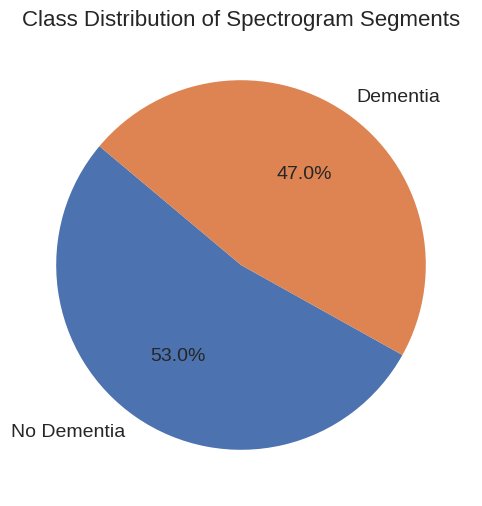


Analyzing audio file durations...


Calculating Durations:   0%|          | 0/192 [00:00<?, ?it/s]

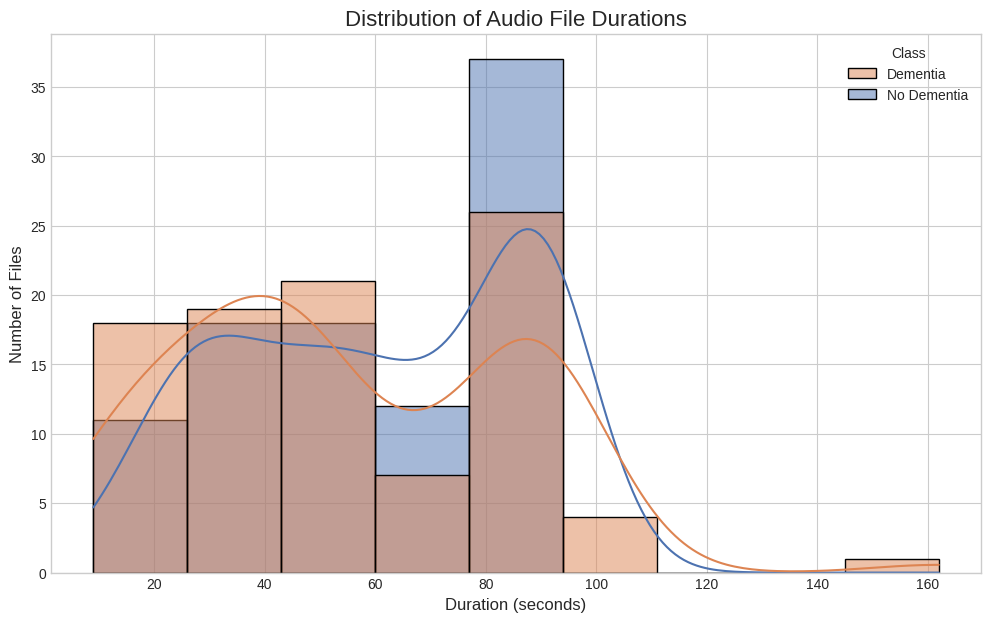

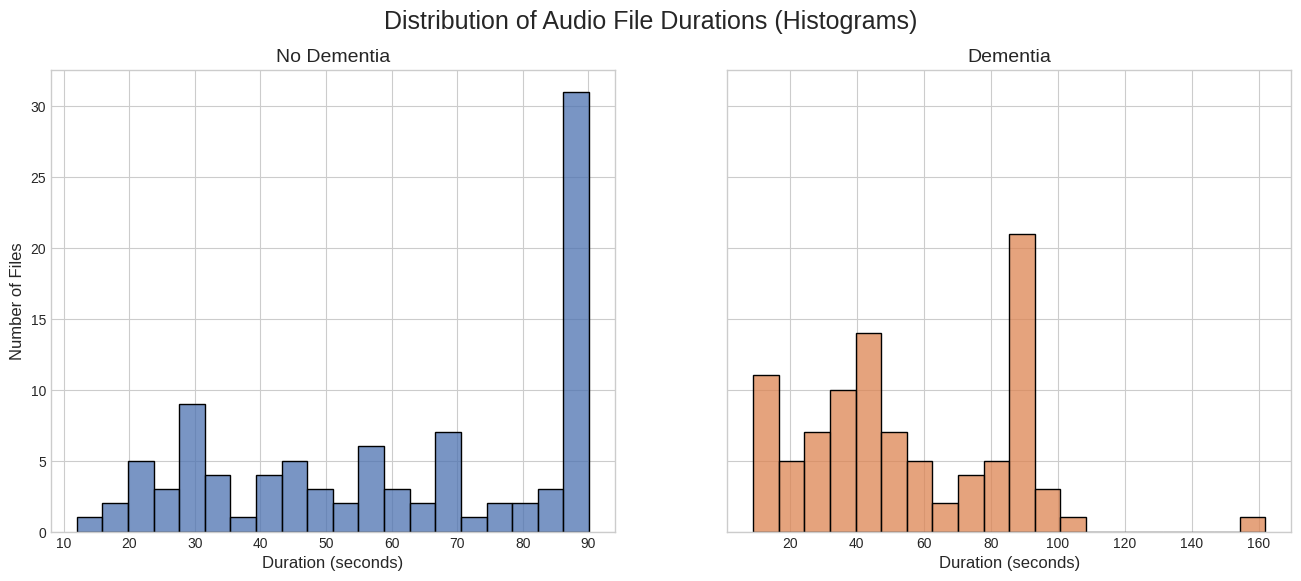

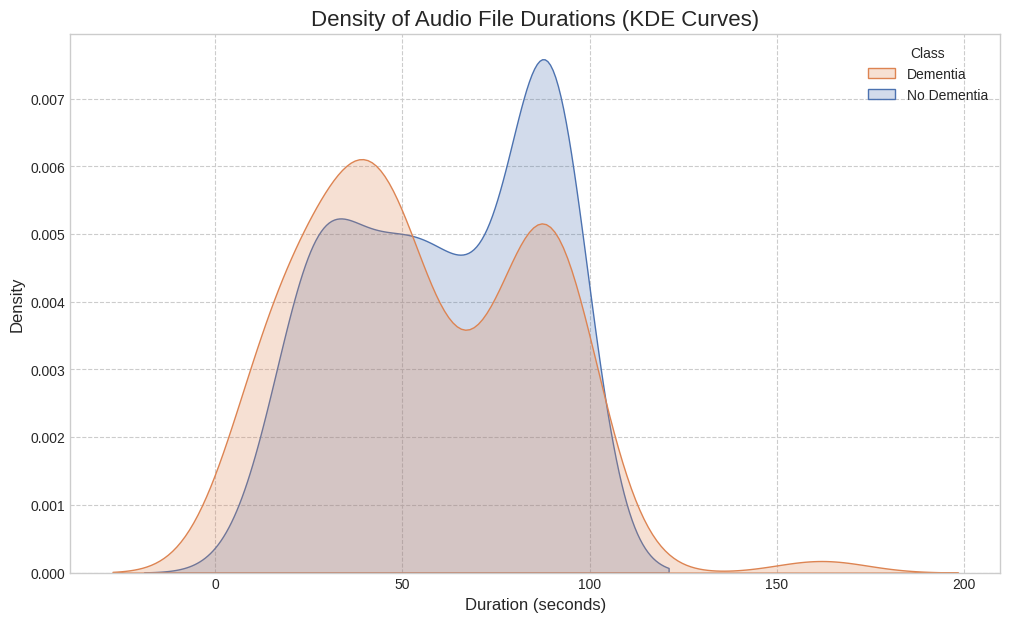


Calculating and plotting average spectrograms...


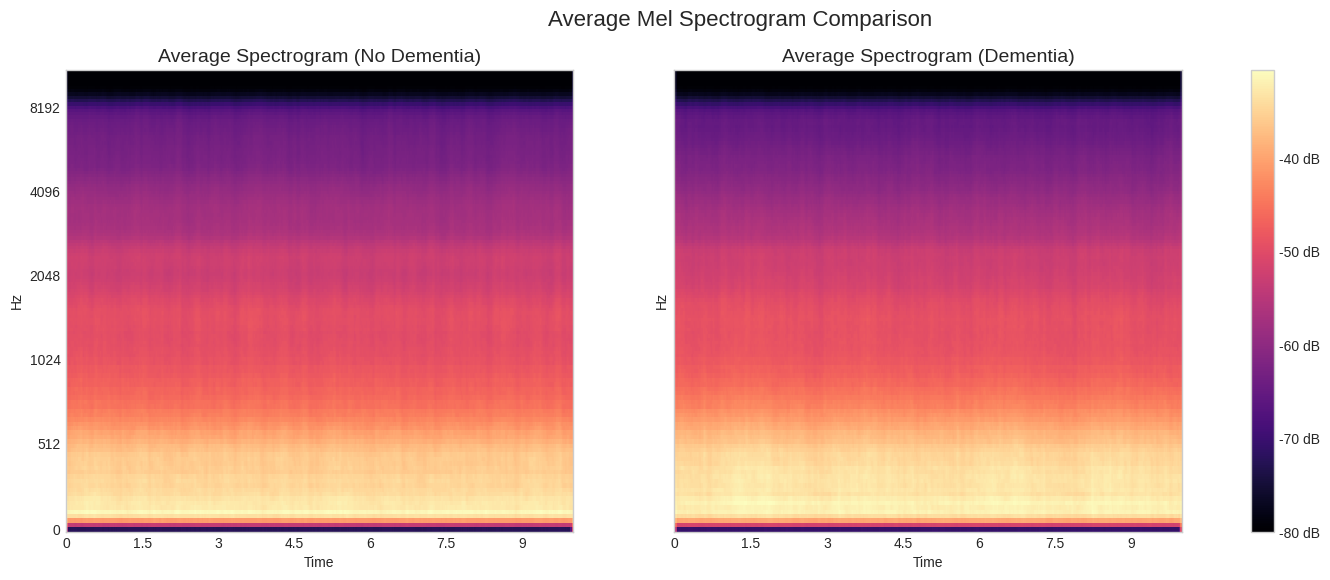


Analyzing mean decibel levels per segment...


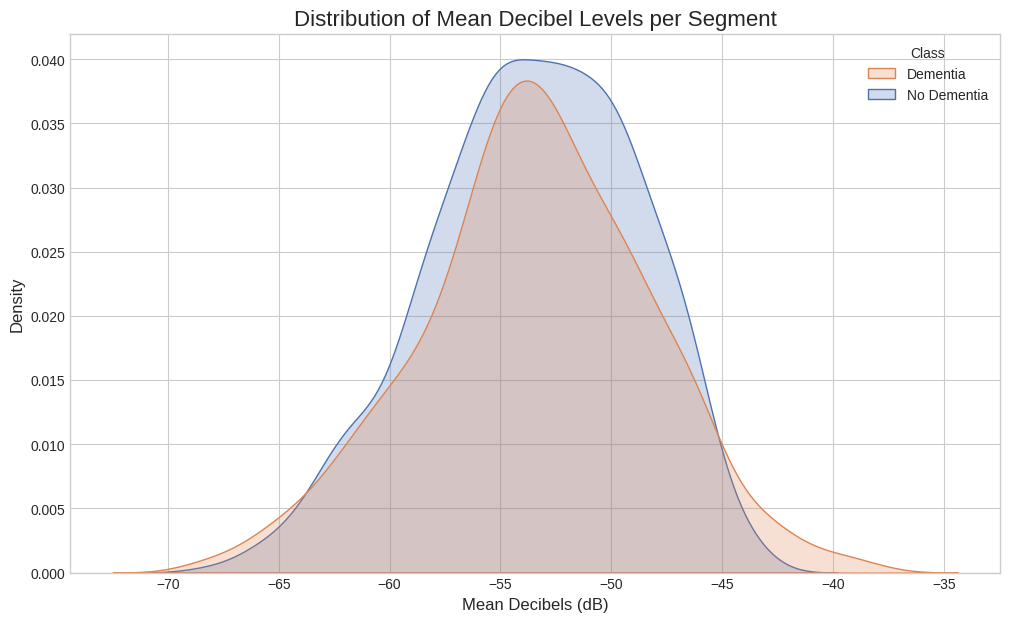

In [ ]:
print("\n--- Exploratory Data Analysis (EDA) ---")

# การกระจายตัวของคลาส (Class Distribution)
# นับจำนวนข้อมูลในแต่ละคลาสจาก y_spec (labels ของ spectrogram segments)
class_counts = pd.Series(y_spec).value_counts()
class_labels = {0: 'No Dementia', 1: 'Dementia'}
class_counts.index = class_counts.index.map(class_labels)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#4C72B0', '#DD8452'], textprops={'fontsize': 14})
plt.title('Class Distribution of Spectrogram Segments', fontsize=16)
plt.ylabel('') # ซ่อนชื่อแกน Y
plt.show()

# การวิเคราะห์ความยาวของไฟล์เสียง (Audio Duration Analysis) สีฟ้า nodementia หรือสีที่ทับ dementia สีส้ม
print("\nAnalyzing audio file durations...")
dementia_durations = []
nodementia_durations = []

# labels ที่ยังไม่ได้แบ่งเป็น segment
original_labels = np.array([1] * len(dementia_files) + [0] * len(nodementia_files))

for path, label in tqdm(zip(file_paths, original_labels), total=len(file_paths), desc="Calculating Durations"):
    try:
        duration = librosa.get_duration(path=path)
        if label == 1:
            dementia_durations.append(duration)
        else:
            nodementia_durations.append(duration)
    except Exception as e:
        print(f"Could not process {path}: {e}")

duration_df = pd.DataFrame({
    'Duration (s)': dementia_durations + nodementia_durations,
    'Class': ['Dementia'] * len(dementia_durations) + ['No Dementia'] * len(nodementia_durations)
})

plt.figure(figsize=(12, 7))
sns.histplot(data=duration_df, x='Duration (s)', hue='Class', kde=True, palette={'No Dementia': '#4C72B0', 'Dementia': '#DD8452'})
plt.title('Distribution of Audio File Durations', fontsize=16)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Number of Files', fontsize=12)
plt.show()

# ความยาวของไฟล์เสียง แบบแยก
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True) # sharey=True เพื่อให้แกน Y เท่ากัน
fig.suptitle('Distribution of Audio File Durations (Histograms)', fontsize=18)

# กราฟแท่งสำหรับกลุ่ม No Dementia
sns.histplot(data=duration_df[duration_df['Class'] == 'No Dementia'], x='Duration (s)',
             color='#4C72B0', ax=ax1, bins=20)
ax1.set_title('No Dementia', fontsize=14)
ax1.set_xlabel('Duration (seconds)', fontsize=12)
ax1.set_ylabel('Number of Files', fontsize=12)

# กราฟแท่งสำหรับกลุ่ม Dementia
sns.histplot(data=duration_df[duration_df['Class'] == 'Dementia'], x='Duration (s)',
             color='#DD8452', ax=ax2, bins=20)
ax2.set_title('Dementia', fontsize=14)
ax2.set_xlabel('Duration (seconds)', fontsize=12)
ax2.set_ylabel('') # ซ่อนชื่อแกน Y ของกราฟที่สอง

plt.show()

# กราฟเส้นโค้ง ที่แยกออกมา บอกแนวโน้วและความหนาแน่น
plt.figure(figsize=(12, 7))
sns.kdeplot(data=duration_df, x='Duration (s)', hue='Class',
            fill=True, # fill=True เพื่อแรเงาพื้นที่ใต้กราฟ
            palette={'No Dementia': '#4C72B0', 'Dementia': '#DD8452'})
plt.title('Density of Audio File Durations (KDE Curves)', fontsize=16)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--')
plt.show()

# ภาพ Spectrogram เฉลี่ย (Average Spectrogram)
print("\nCalculating and plotting average spectrograms...")
# แยก spectrogram ตามคลาส
dementia_specs = X_spec[y_spec == 1]
nodementia_specs = X_spec[y_spec == 0]

# คำนวณค่าเฉลี่ยของ spectrogram ในแต่ละคลาส
avg_dementia_spec = np.mean(dementia_specs, axis=0).squeeze()
avg_nodementia_spec = np.mean(nodementia_specs, axis=0).squeeze()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle('Average Mel Spectrogram Comparison', fontsize=16)

# กราฟ Average Spectrogram ของกลุ่ม No Dementia
img1 = librosa.display.specshow(avg_nodementia_spec, sr=SR, hop_length=512, x_axis='time', y_axis='mel', ax=ax1)
ax1.set_title('Average Spectrogram (No Dementia)', fontsize=14)

# กราฟ Average Spectrogram ของกลุ่ม Dementia
img2 = librosa.display.specshow(avg_dementia_spec, sr=SR, hop_length=512, x_axis='time', y_axis='mel', ax=ax2)
ax2.set_title('Average Spectrogram (Dementia)', fontsize=14)

fig.colorbar(img1, ax=[ax1, ax2], format='%+2.0f dB')
plt.show()

# การกระจายตัวของระดับความดัง (Mean Decibel Analysis)
print("\nAnalyzing mean decibel levels per segment...")
mean_db_dementia = np.mean(dementia_specs, axis=(1, 2, 3))
mean_db_nodementia = np.mean(nodementia_specs, axis=(1, 2, 3))

db_df = pd.DataFrame({
    'Mean dB': np.concatenate([mean_db_dementia, mean_db_nodementia]),
    'Class': ['Dementia'] * len(mean_db_dementia) + ['No Dementia'] * len(mean_db_nodementia)
})

plt.figure(figsize=(12, 7))
sns.kdeplot(data=db_df, x='Mean dB', hue='Class', fill=True, palette={'No Dementia': '#4C72B0', 'Dementia': '#DD8452'})
plt.title('Distribution of Mean Decibel Levels per Segment', fontsize=16)
plt.xlabel('Mean Decibels (dB)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

## Build Train Model and Evaluate

### CNN Standard

In [ ]:
# CNN ธรรมดา
def create_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# กำหนด input shape และสร้างโมเดล
model_cnn = create_cnn_model(X_train_spec.shape[1:])
model_cnn.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 431, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 431, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 431, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 431, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 215, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64, 215, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 215, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 215, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 215, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 215, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 107, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 107, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 107, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 107, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 107, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 107, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 108544)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    27,787,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 28,110,305 (107.23 MB)

 Trainable params: 28,108,641 (107.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

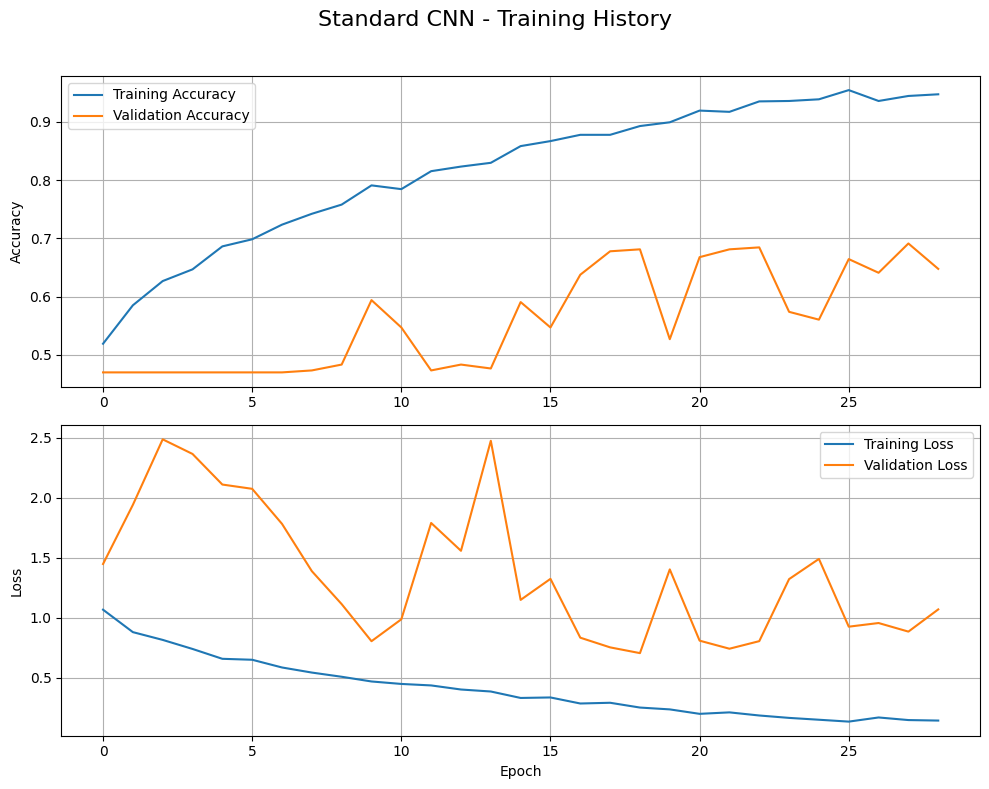

In [ ]:
#ทำกา Train Standard CNN พร้อมวัดเวลา และแสดงกราฟผลลัพธ์การฝึก Training History
start_time = time.time()
history_cnn = model_cnn.fit(X_train_spec, y_train_spec, epochs=50, batch_size=32,
                            validation_data=(X_val_spec, y_val_spec),
                            # EarlyStopping กัน Overfitting (การที่โมเดลจดจำข้อมูลที่ใช้ฝึกได้ดีเกินไป แต่ทำงานได้ไม่ดีกับข้อมูลใหม่ที่ไม่เคยเห็น)
                            # patience= 10 หากค่า val_loss ไม่ลดลง ติดต่อกันเป็นเวลา 10 epochs จะหยุด
                            # restore_best_weights=True ย้อนกลับไปใช้ weights ของโมเดลจาก Epoch ที่มีค่า val_loss ต่ำที่สุด
                            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                            verbose=0)
train_time_cnn = time.time() - start_time
plot_history(history_cnn, "Standard CNN")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
CNN Test Accuracy: 0.6455


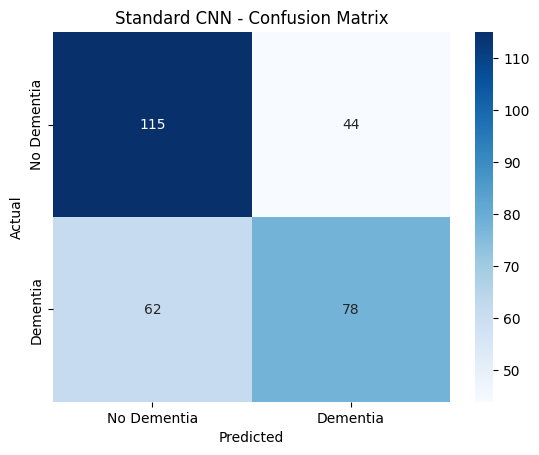


Classification Report:
              precision    recall  f1-score   support

 No Dementia       0.65      0.72      0.68       159
    Dementia       0.64      0.56      0.60       140

    accuracy                           0.65       299
   macro avg       0.64      0.64      0.64       299
weighted avg       0.64      0.65      0.64       299



In [ ]:
# Evaluate
# วัดประสิทธิภาพของโมเดลกับข้อมูล Test Set พร้อมจับเวลา และแสดงผลลัพธ์เป็นค่า Accuracy, Confusion Matrix, และ Classification Report
start_time = time.time()
loss_cnn, acc_cnn = model_cnn.evaluate(X_test_spec, y_test_spec, verbose=0)
infer_time_cnn = time.time() - start_time
y_pred_cnn = (model_cnn.predict(X_test_spec) > 0.5).astype("int32") #Threshold มากกว่า 0.5 จะได้ผลลัพธ์เป็น True  น้อยกว่าหรือเท่ากับ 0.5 จะได้ผลลัพธ์เป็น False

performance_summary['Standard CNN'] = {
    'Test Accuracy': acc_cnn,
    'Test Loss': loss_cnn,
    'Training Time (s)': train_time_cnn,
    'Inference Time (s)': infer_time_cnn
}

print(f"CNN Test Accuracy: {acc_cnn:.4f}")
cm_cnn = confusion_matrix(y_test_spec, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=['No Dementia', 'Dementia'], yticklabels=['No Dementia', 'Dementia'])
plt.title('Standard CNN - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

print("\nClassification Report:")
print(classification_report(y_test_spec, y_pred_cnn, target_names=['No Dementia', 'Dementia']))

###SpectroAttenCNN

In [ ]:
#  SpectroAttenCNN

def channel_attention(input_feature):
    """A simple channel attention mechanism."""
    channel_axis = -1
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    # Reshape to (batch_size, 1, 1, channels) for dense layers
    feature = layers.Reshape((1, 1, avg_pool.shape[1]))(avg_pool)

    # Use dense layers to learn channel importance
    dense_1 = layers.Dense(units=feature.shape[-1] // 8, activation='relu', kernel_initializer='he_normal', use_bias=True)(feature)
    dense_2 = layers.Dense(units=feature.shape[-1], activation='sigmoid', kernel_initializer='he_normal', use_bias=True)(dense_1)

    # Multiply the attention weights with the input feature map
    return layers.multiply([input_feature, dense_2])

def create_attention_cnn_model(input_shape):
    """Creates the CNN model with attention, based on the paper's architecture."""
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Attention Mechanism
    x = channel_attention(x)

    # Fully Connected Layers
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Output Layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# กำหนด input shape และสร้างโมเดล
model_att_cnn = create_attention_cnn_model(X_train_spec.shape[1:])
model_att_cnn.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 431,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 431,  │        320 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 431,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 215,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 215,   │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 215,   │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 107,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 107,   │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 107,   │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 53,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_11… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 128) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 1, 16)  │      2,064 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 1, 128) │      2,176 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 16, 53,    │          0 │ max_pooling2d_11… │
│ (Multiply)          │ 128)              │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 108544)    │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 108544)    │          0 │ flatten_3[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │ 27,787,520 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 27,886,609 (106.38 MB)

 Trainable params: 27,885,649 (106.38 MB)

 Non-trainable params: 960 (3.75 KB)

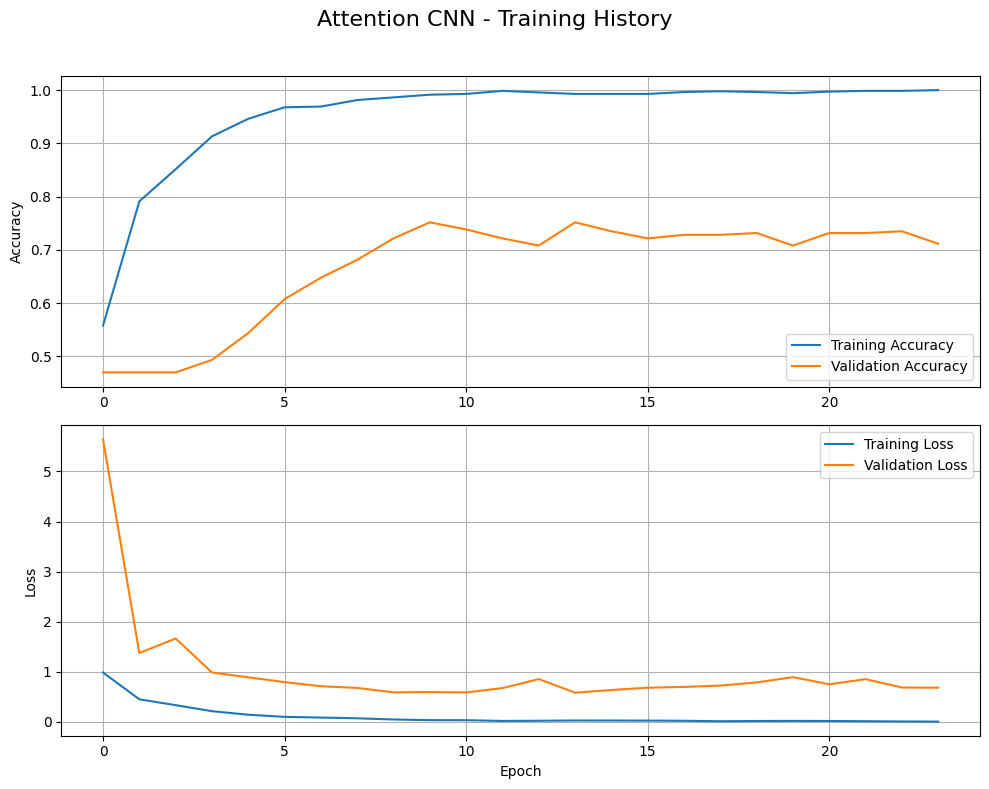

In [ ]:
# ทำการ Train Attention CNN พร้อมวัดเวลา และแสดงกราฟผลลัพธ์การฝึก (Training History)
start_time = time.time()
history_att_cnn = model_att_cnn.fit(X_train_spec, y_train_spec, epochs=50, batch_size=32,
                                    validation_data=(X_val_spec, y_val_spec),
                                    #เหมือนกันกับ CNN
                                    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                                    verbose=0)
train_time_att_cnn = time.time() - start_time
plot_history(history_att_cnn, "Attention CNN")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Attention CNN Test Accuracy: 0.7258


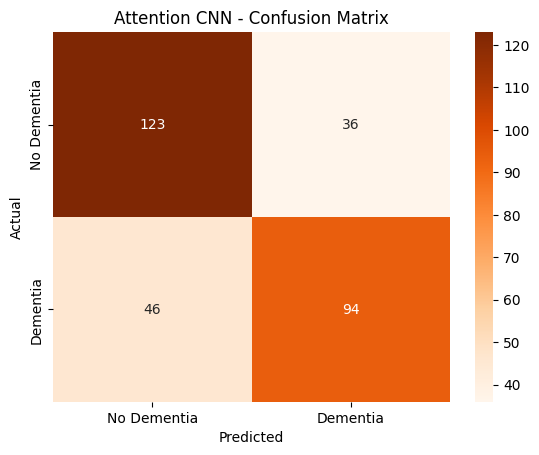


Classification Report:
              precision    recall  f1-score   support

 No Dementia       0.73      0.77      0.75       159
    Dementia       0.72      0.67      0.70       140

    accuracy                           0.73       299
   macro avg       0.73      0.72      0.72       299
weighted avg       0.73      0.73      0.72       299



In [ ]:
# วัดประสิทธิภาพของโมเดล Attention CNN กับข้อมูล Test Set พร้อมจับเวลา และแสดงผลลัพธ์เป็นค่า Accuracy, Confusion Matrix, และ Classification Report
#Evaluate
start_time = time.time()
loss_att_cnn, acc_att_cnn = model_att_cnn.evaluate(X_test_spec, y_test_spec, verbose=0)
infer_time_att_cnn = time.time() - start_time
y_pred_att_cnn = (model_att_cnn.predict(X_test_spec) > 0.5).astype("int32") #Threshold มากกว่า 0.5 จะได้ผลลัพธ์เป็น True  น้อยกว่าหรือเท่ากับ 0.5 จะได้ผลลัพธ์เป็น False

performance_summary['Attention CNN'] = {
    'Test Accuracy': acc_att_cnn,
    'Test Loss': loss_att_cnn,
    'Training Time (s)': train_time_att_cnn,
    'Inference Time (s)': infer_time_att_cnn
}

print(f"Attention CNN Test Accuracy: {acc_att_cnn:.4f}")
cm_att_cnn = confusion_matrix(y_test_spec, y_pred_att_cnn)
sns.heatmap(cm_att_cnn, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Dementia', 'Dementia'], yticklabels=['No Dementia', 'Dementia'])
plt.title('Attention CNN - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()
print("\nClassification Report:")
print(classification_report(y_test_spec, y_pred_att_cnn, target_names=['No Dementia', 'Dementia']))

### Ridge Classifier (Machine Learning)
https://arxiv.org/abs/2502.03484?utm_source=chatgpt.com

In [ ]:
# openSMILE features
# สร้างชุดข้อมูลสำหรับโมเดล Machine Learning โดยใช้ openSMILE สกัดfeatures  จากไฟล์เสียงทั้งหมด
smile = opensmile.Smile(feature_set=opensmile.FeatureSet.ComParE_2016, feature_level=opensmile.FeatureLevel.Functionals)
features_list = []
SR_OS = 16000 # Use 16kHz sample rate as specified in the paper [cite: 163]

for file_path in tqdm(file_paths, desc="Processing openSMILE Features"):
    try:
        # Librosa loads and resamples the audio to 16kHz
        audio, sr = librosa.load(file_path, sr=SR_OS)
        # Extract features using openSMILE
        # This returns a pandas DataFrame with one row of features
        features = smile.process_signal(audio, sr)
        features_list.append(features.iloc[0].values)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        #  Add a placeholder for the failed file to maintain label alignment
        if features_list: features_list.append(np.zeros_like(features_list[0]))

# Convert the list of feature arrays into a single NumPy matrix
X_os = np.array(features_list)
y_os = np.array(labels)

# Remove any features that have zero variance
variances = np.var(X_os, axis=0)
X_os = X_os[:, variances > 0]

print(f"openSMILE feature matrix shape: {X_os.shape}")
print(f"Labels shape: {y_os.shape}")

Processing openSMILE Features:   0%|          | 0/192 [00:00<?, ?it/s]

openSMILE feature matrix shape: (192, 6371)
Labels shape: (192,)


In [ ]:
# Define Pipeline
ridge_clf = RidgeClassifier(alpha=1.0, random_state=42)
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('feature_selection', SelectFromModel(ridge_clf, threshold='median')),  #Select features with importance above the median
    ('classification', ridge_clf)
])

LOSO Cross-Validation:   0%|          | 0/192 [00:00<?, ?it/s]

Ridge Classifier LOSO Accuracy: 0.5885


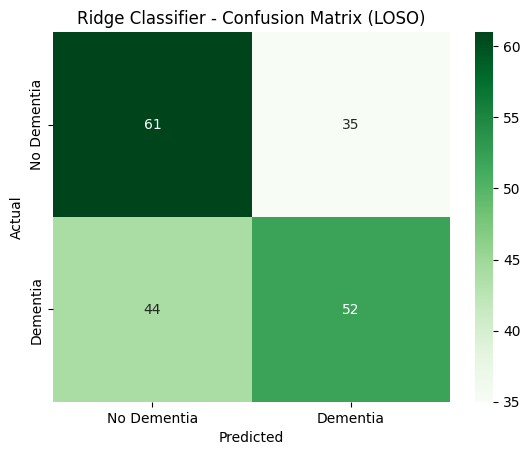


Classification Report:
              precision    recall  f1-score   support

 No Dementia       0.58      0.64      0.61        96
    Dementia       0.60      0.54      0.57        96

    accuracy                           0.59       192
   macro avg       0.59      0.59      0.59       192
weighted avg       0.59      0.59      0.59       192



In [ ]:
# Evaluate with LOSO  (Leave-One-Subject-Out Cross-Validation)
loso = LeaveOneOut()
y_true_ridge, y_pred_ridge = [], []

start_time = time.time()
for train_index, test_index in tqdm(loso.split(X_os), total=len(X_os), desc="LOSO Cross-Validation"):
    X_train_os, X_test_os = X_os[train_index], X_os[test_index]
    y_train_os, y_test_os = y_os[train_index], y_os[test_index]
    # Fit the entire pipeline on the training data
    pipeline.fit(X_train_os, y_train_os)
    # Make a prediction on the single left-out subject
    prediction = pipeline.predict(X_test_os)
    # Store the true label and the prediction
    y_true_ridge.extend(y_test_os); y_pred_ridge.extend(prediction)

train_time_ridge = time.time() - start_time
acc_ridge = accuracy_score(y_true_ridge, y_pred_ridge)

performance_summary['Ridge Classifier (LOSO)'] = {
    'Test Accuracy': acc_ridge,
    'Test Loss': 'N/A', # LOSO doesn't have a single test loss
    'Training Time (s)': train_time_ridge,
    'Inference Time (s)': 'N/A' # Included in training time
}

# Results
print(f"Ridge Classifier LOSO Accuracy: {acc_ridge:.4f}")
cm_ridge = confusion_matrix(y_true_ridge, y_pred_ridge)
sns.heatmap(cm_ridge, annot=True, fmt='d', cmap='Greens', xticklabels=['No Dementia', 'Dementia'], yticklabels=['No Dementia', 'Dementia'])
plt.title('Ridge Classifier - Confusion Matrix (LOSO)'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

print("\nClassification Report:")
print(classification_report(y_true_ridge, y_pred_ridge, target_names=['No Dementia', 'Dementia']))

### DT-Net (Resnet)

In [ ]:
def create_resnet_model(input_shape):
    '''
    ResNet50 คือเอา pre-trained มาใช้
    Non-trainable params: 23,587,712 คือจำนวนพารามิเตอร์ที่ "ถูกแช่แข็ง" (Frozen) และจะไม่ถูกอัปเดตระหว่างการฝึก ซึ่งทั้งหมดนี้ก็คือพารามิเตอร์ของชั้น resnet50
    '''
    # สร้างโมเดล ResNet50 ด้วยเทคนิค Transfer Learning
    # 1. สร้าง Input Layer สำหรับข้อมูล (1 channel)
    inputs = tf.keras.Input(shape=input_shape)

    # 2. เพิ่ม Layer เพื่อแปลง 1 channel -> 3 channels แล้วเพื่อให้ layer เท่ากันกับ CNN
    x = layers.Conv2D(3, (1, 1), padding='same')(inputs)

    # 3. โหลด ResNet50 โดยไม่ส่ง input_tensor เข้าไปตรงๆ แต่กำหนด input_shape
    #    และตั้งค่าให้ base_model สามารถรับข้อมูลจาก layer ก่อนหน้าได้
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(input_shape[0], input_shape[1], 3))

    # Freeze layers ของ base model
    base_model.trainable = False

    # 4. นำข้อมูล 3 channels ของเราส่งเข้า base_model
    x = base_model(x, training=False)

    # 5. เพิ่มส่วนหัว (classifier) ที่สร้างเอง
    x = layers.GlobalAveragePooling2D()(x) #ค่าเฉลี่ยของ Feature Map ลดจำนวนพารามิเตอร์และป้องกัน Overfitting
    x = layers.Dense(256, activation='relu')(x) #  Fully Connected layer
    x = layers.Dropout(0.5)(x) # Regularization ที่ช่วยป้องกัน Overfitting
    outputs = layers.Dense(1, activation='sigmoid')(x) #สำหรับ Binary Classification

    model = tf.keras.Model(inputs, outputs)

    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
# สร้างโมเดล
model_resnet = create_resnet_model(X_train_spec.shape[1:])
model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 431, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 431, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 14, 2048)    │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,519 (91.98 MB)

 Trainable params: 524,807 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 52s 684ms/step - accuracy: 0.5141 - loss: 0.8322 - val_accuracy: 0.5872 - val_loss: 0.6749
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 211ms/step - accuracy: 0.5760 - loss: 0.7114 - val_accuracy: 0.6275 - val_loss: 0.6469
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.6263 - loss: 0.6472 - val_accuracy: 0.6611 - val_loss: 0.6288
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.6691 - loss: 0.6069 - val_accuracy: 0.6577 - val_loss: 0.6149
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.7089 - loss: 0.5626 - val_accuracy: 0.6611 - val_loss: 0.6131
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.6967 - loss: 0.5729 - val_accuracy: 0.7047 - val_loss: 0.6015
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.7126 - loss: 0.5665 - val_accuracy: 0.6745 - val_loss: 0.5980
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 207ms/step - accuracy: 0.7319 - loss: 0.5435 - val_accu

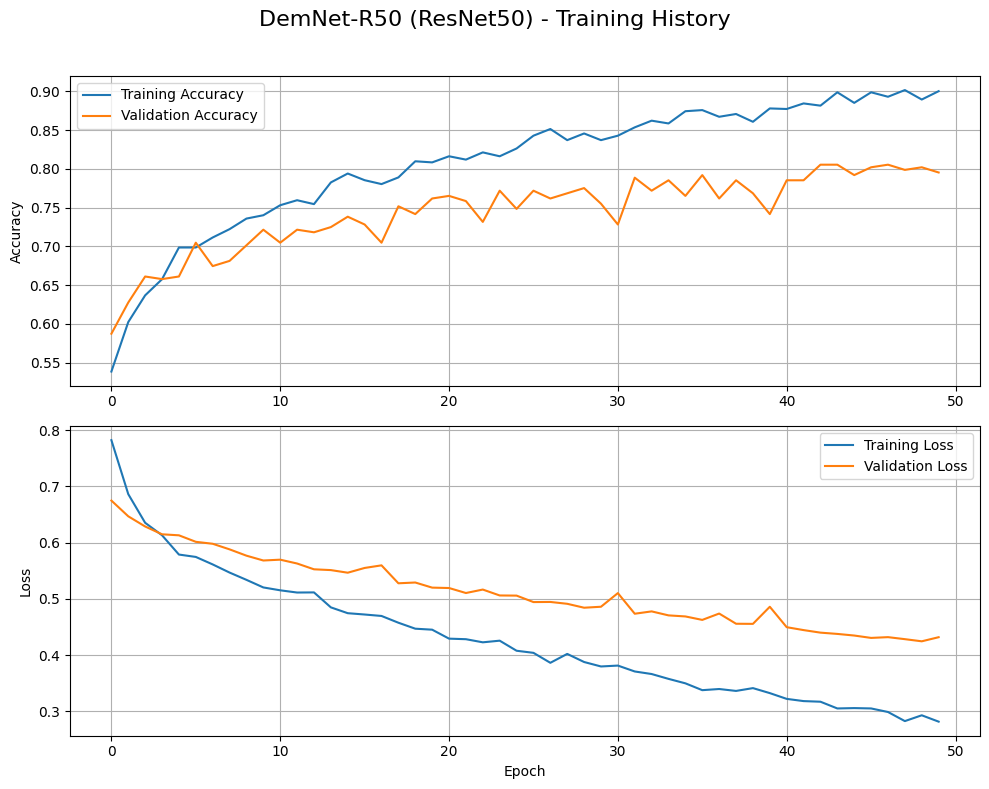

In [ ]:
# Train
start_time = time.time()
history_resnet = model_resnet.fit(X_train_spec, y_train_spec, epochs=50, batch_size=32,
                                  validation_data=(X_val_spec, y_val_spec),
                                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                                  verbose=1)
train_time_resnet = time.time() - start_time

# แสดงกราฟผลการฝึก
plot_history(history_resnet, "ResNet50")


DT-Net Test Accuracy: 0.7993

--- DT-Net Results Visualization ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


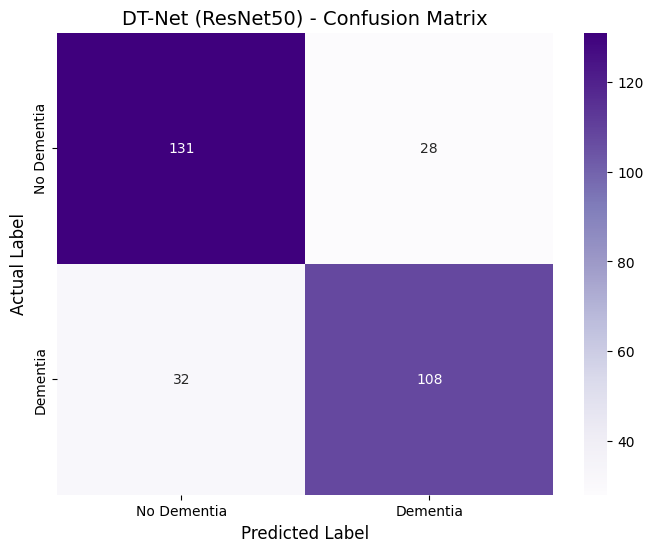


Classification Report (DT-Net):
              precision    recall  f1-score   support

 No Dementia       0.80      0.82      0.81       159
    Dementia       0.79      0.77      0.78       140

    accuracy                           0.80       299
   macro avg       0.80      0.80      0.80       299
weighted avg       0.80      0.80      0.80       299



In [ ]:
# 50 epoch
start_time = time.time()
loss_resnet, acc_resnet = model_resnet.evaluate(X_test_spec, y_test_spec, verbose=0)
infer_time_resnet = time.time() - start_time

# บันทึกผลลัพธ์ลงใน dictionary
performance_summary['DT-Net'] = {
    'Test Accuracy': acc_resnet,
    'Test Loss': loss_resnet,
    'Training Time (s)': train_time_resnet,
    'Inference Time (s)': infer_time_resnet
}

print(f"\nDT-Net Test Accuracy: {acc_resnet:.4f}")
# แสดงผลลัพธ์ Confusion Matrix และ Classification Report
print("\n--- DT-Net Results Visualization ---")

# ทำนายผลกับข้อมูล Test Set เพื่อนำไปสร้าง Confusion Matrix
y_pred_resnet_probs = model_resnet.predict(X_test_spec)
y_pred_resnet = (y_pred_resnet_probs > 0.5).astype("int32")

# คำนวณและสร้างกราฟ Confusion Matrix
cm_resnet = confusion_matrix(y_test_spec, y_pred_resnet)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Dementia', 'Dementia'],
            yticklabels=['No Dementia', 'Dementia'])
plt.title('DT-Net (ResNet50) - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# แสดงผล Classification Report
print("\nClassification Report (DT-Net):")
print(classification_report(y_test_spec, y_pred_resnet, target_names=['No Dementia', 'Dementia']))

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5361 - loss: 0.8251
Epoch 1: val_loss improved from inf to 0.64407, saving model to best_resnet_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 658ms/step - accuracy: 0.5366 - loss: 0.8238 - val_accuracy: 0.6275 - val_loss: 0.6441
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5886 - loss: 0.6734
Epoch 2: val_loss improved from 0.64407 to 0.62630, saving model to best_resnet_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 220ms/step - accuracy: 0.5889 - loss: 0.6733 - val_accuracy: 0.6309 - val_loss: 0.6263
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6427 - loss: 0.6170
Epoch 3: val_loss improved from 0.62630 to 0.62345, saving model to best_resnet_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - accuracy: 0.6424 - loss: 0.6174 - val_accuracy: 0.6678 - val_loss: 0.6235
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7006 - loss: 0.5780
Epoch 4: val_loss improved 

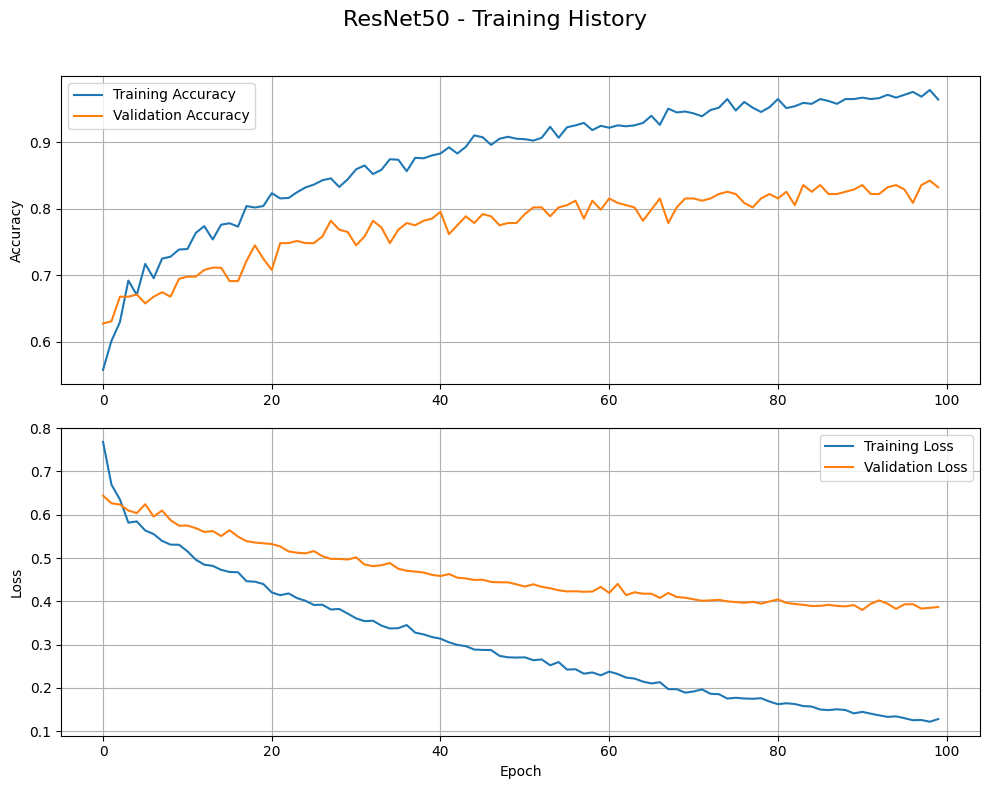

In [ ]:
# Train 100 epoch
early_stopping_resnet = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model_checkpoint_resnet = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_resnet_model.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

start_time = time.time()
history_resnet = model_resnet.fit(X_train_spec, y_train_spec, epochs=100, batch_size=32,
                                  validation_data=(X_val_spec, y_val_spec),

                                  callbacks=[early_stopping_resnet, model_checkpoint_resnet],
                                  verbose=1)
train_time_resnet = time.time() - start_time

# แสดงกราฟผลการฝึก
plot_history(history_resnet, "ResNet50")


DT-Net Test Accuracy: 0.8629

--- DT-Net Results Visualization ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 599ms/step


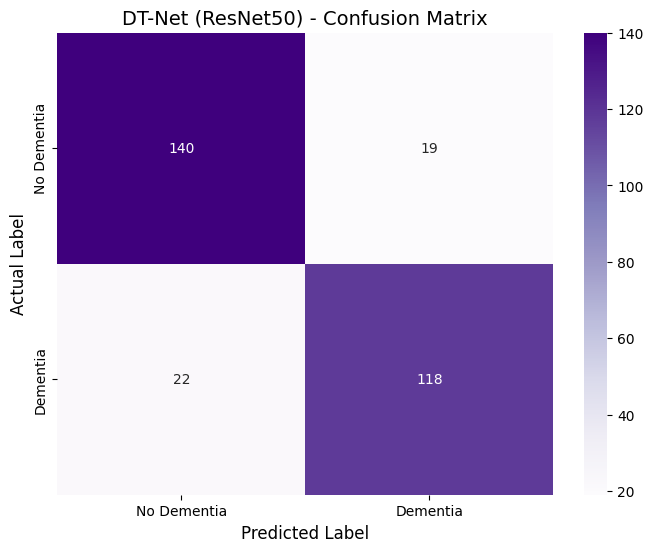


Classification Report (DT-Net):
              precision    recall  f1-score   support

 No Dementia       0.86      0.88      0.87       159
    Dementia       0.86      0.84      0.85       140

    accuracy                           0.86       299
   macro avg       0.86      0.86      0.86       299
weighted avg       0.86      0.86      0.86       299



In [ ]:
#100 epoch
start_time = time.time()
loss_resnet, acc_resnet = model_resnet.evaluate(X_test_spec, y_test_spec, verbose=0)
infer_time_resnet = time.time() - start_time

# บันทึกผลลัพธ์ลงใน dictionary
performance_summary['DT-Net'] = {
    'Test Accuracy': acc_resnet,
    'Test Loss': loss_resnet,
    'Training Time (s)': train_time_resnet,
    'Inference Time (s)': infer_time_resnet
}

print(f"\nDT-Net Test Accuracy: {acc_resnet:.4f}")
# แสดงผลลัพธ์ Confusion Matrix และ Classification Report
print("\n--- DT-Net Results Visualization ---")

# ทำนายผลกับข้อมูล Test Set เพื่อนำไปสร้าง Confusion Matrix
y_pred_resnet_probs = model_resnet.predict(X_test_spec)
y_pred_resnet = (y_pred_resnet_probs > 0.5).astype("int32")

# คำนวณและสร้างกราฟ Confusion Matrix
cm_resnet = confusion_matrix(y_test_spec, y_pred_resnet)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Dementia', 'Dementia'],
            yticklabels=['No Dementia', 'Dementia'])
plt.title('DT-Net (ResNet50) - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# แสดงผล Classification Report
print("\nClassification Report (DT-Net):")
print(classification_report(y_test_spec, y_pred_resnet, target_names=['No Dementia', 'Dementia']))

# Final Model Comparison

                         Test Accuracy  Test Loss  Training Time (s)  \
Standard CNN                  0.645485   0.658158         358.783045   
Ridge Classifier (LOSO)       0.588542        NaN          14.551647   
DT-Net                        0.862876   0.321199        1147.243589   
SpectroAttenCNN               0.725753   0.662239         117.076759   

                         Inference Time (s)  
Standard CNN                       0.896048  
Ridge Classifier (LOSO)                 NaN  
DT-Net                             4.593222  
SpectroAttenCNN                    0.429478  


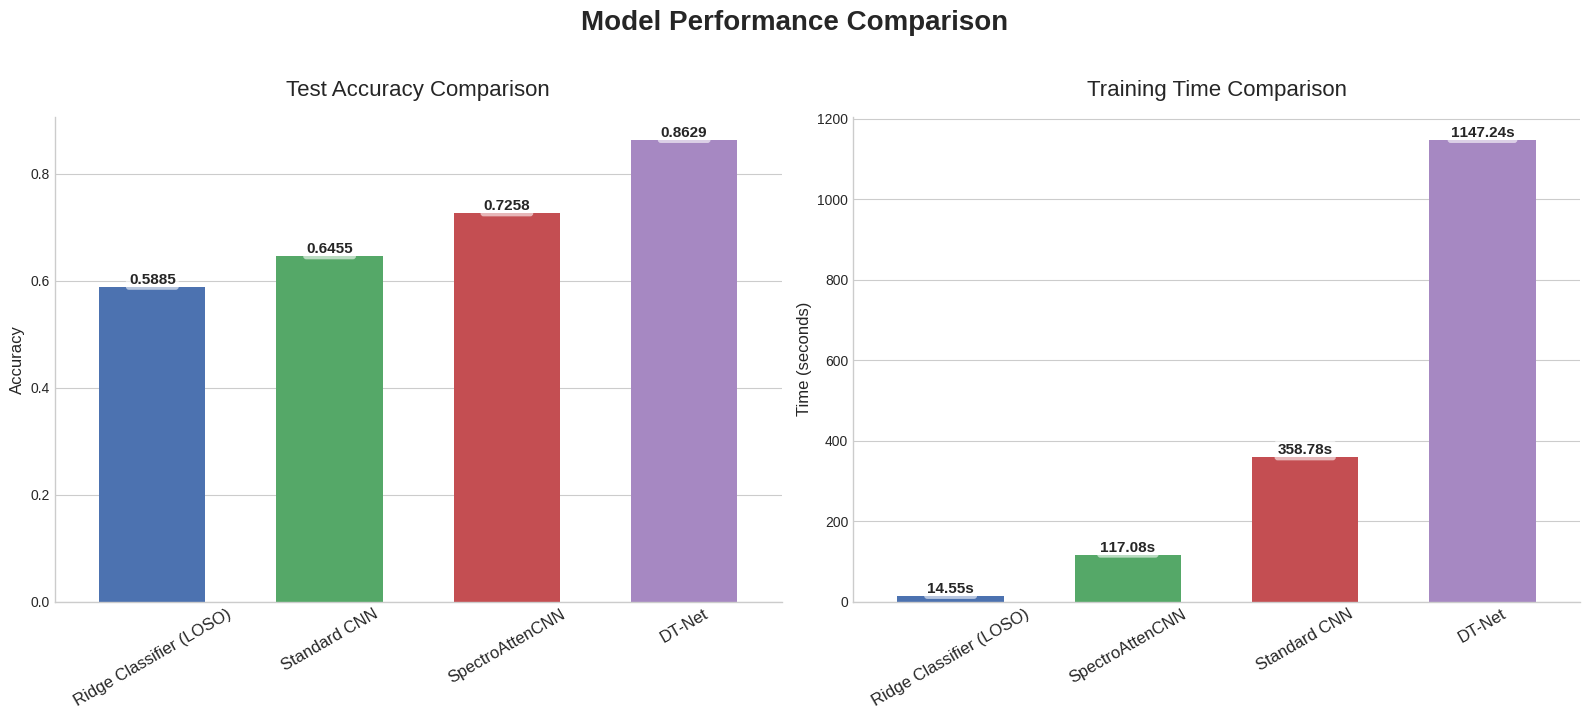

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# แปลง Dictionary เป็น DataFrame
summary_df = pd.DataFrame.from_dict(performance_summary, orient='index')
print(summary_df)

# สร้างกราฟเปรียบเทียบ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Model Performance Comparison', fontsize=20, weight='bold', y=1.02)

colors = ['#4C72B0', '#55A868', '#C44E52', '#A688C2']

# กราฟที่ 1: เปรียบเทียบ Test Accuracy
summary_df['Test Accuracy'].sort_values().plot(kind='bar', ax=ax1, color=colors, width=0.6)
ax1.set_title('Test Accuracy Comparison', fontsize=16, pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=30, labelsize=12)
ax1.grid(axis='x', visible=False)
ax1.spines[['top', 'right']].set_visible(False)

# เพิ่มตัวเลขกำกับแท่งกราฟ
for index, value in enumerate(summary_df['Test Accuracy'].sort_values()):
    ax1.text(index, value, f'{value:.4f}', ha='center', va='bottom', fontsize=11, weight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))


# กราฟที่ 2: เปรียบเทียบ Training Time
summary_df['Training Time (s)'].sort_values().plot(kind='bar', ax=ax2, color=colors, width=0.6)
ax2.set_title('Training Time Comparison', fontsize=16, pad=15)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=30, labelsize=12)
ax2.grid(axis='x', visible=False)
ax2.spines[['top', 'right']].set_visible(False)

# เพิ่มตัวเลขกำกับแท่งกราฟ
for index, value in enumerate(summary_df['Training Time (s)'].sort_values()):
    ax2.text(index, value, f'{value:.2f}s', ha='center', va='bottom', fontsize=11, weight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))


plt.tight_layout()
plt.show()

                         Test Accuracy  Test Loss  Training Time (s)  \
DT-Net                        0.862876   0.321199        1147.243589   
Ridge Classifier (LOSO)       0.588542        NaN          14.551647   
SpectroAttenCNN               0.725753   0.662239         117.076759   
Standard CNN                  0.645485   0.658158         358.783045   

                         Inference Time (s)  
DT-Net                             4.593222  
Ridge Classifier (LOSO)                 NaN  
SpectroAttenCNN                    0.429478  
Standard CNN                       0.896048  


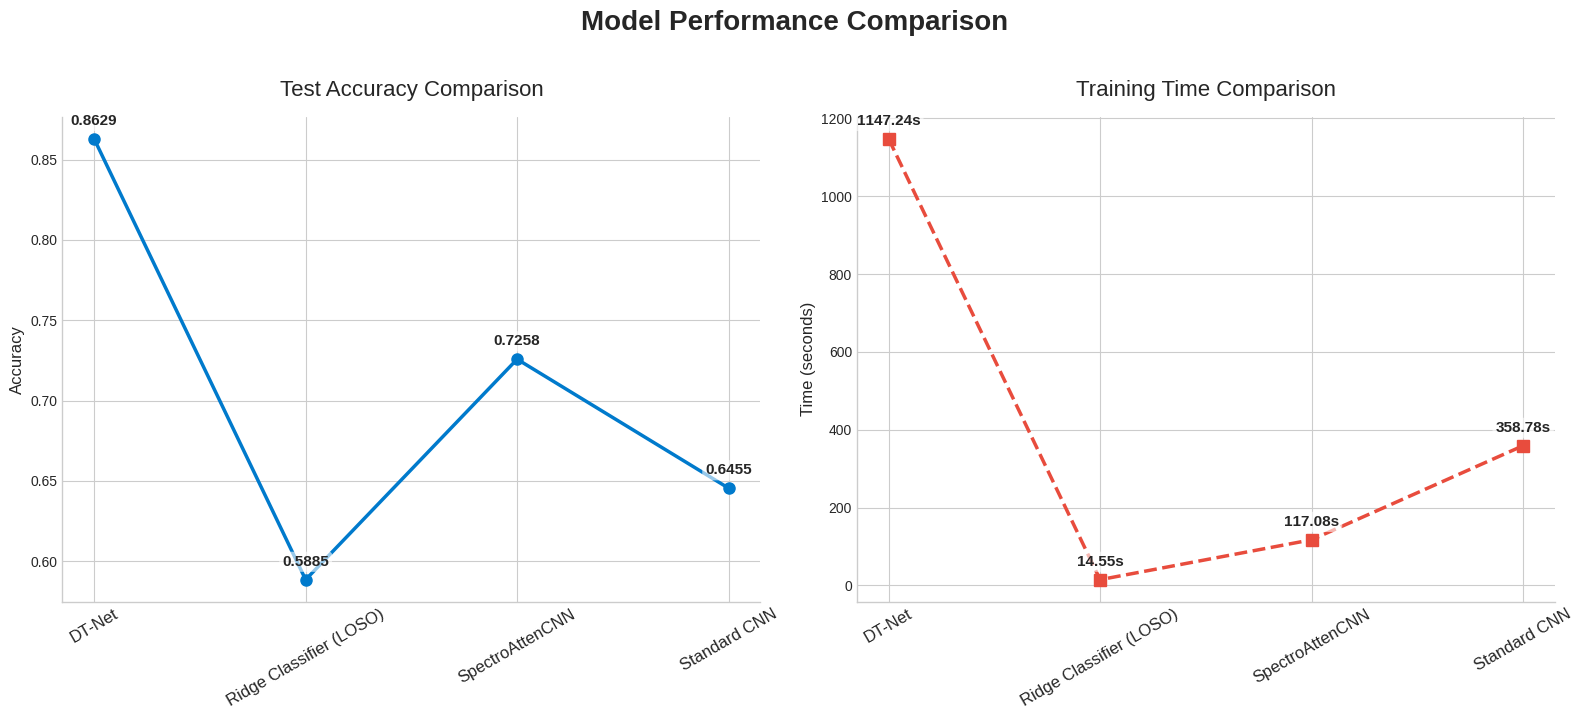

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# แปลง Dictionary เป็น DataFrame และเรียงลำดับ
summary_df = pd.DataFrame.from_dict(performance_summary, orient='index')
summary_df = summary_df.sort_index()
print(summary_df)

# สร้างกราฟเปรียบเทียบ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Model Performance Comparison', fontsize=20, weight='bold', y=1.02)

colors = {'Test Accuracy': '#007ACC', 'Training Time (s)': '#E84C3D'}

# --- กราฟที่ 1: เปรียบเทียบ Test Accuracy ---
ax1.plot(summary_df.index, summary_df['Test Accuracy'], marker='o', linestyle='-', color=colors['Test Accuracy'], linewidth=2.5, markersize=8)
ax1.set_title('Test Accuracy Comparison', fontsize=16, pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('') # ไม่ต้องแสดงชื่อแกน X
ax1.tick_params(axis='x', rotation=30, labelsize=12)
ax1.spines[['top', 'right']].set_visible(False) # เอากรอบด้านบนและขวาออก

# เพิ่มตัวเลขกำกับจุด
for i, txt in enumerate(summary_df['Test Accuracy']):
    ax1.annotate(f'{txt:.4f}', (summary_df.index[i], summary_df['Test Accuracy'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, weight='bold',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))


# กราฟที่ 2: เปรียบเทียบ Training Time
ax2.plot(summary_df.index, summary_df['Training Time (s)'], marker='s', linestyle='--', color=colors['Training Time (s)'], linewidth=2.5, markersize=8)
ax2.set_title('Training Time Comparison', fontsize=16, pad=15)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=30, labelsize=12)
ax2.spines[['top', 'right']].set_visible(False)

# เพิ่มตัวเลขกำกับจุด
for i, txt in enumerate(summary_df['Training Time (s)']):
    ax2.annotate(f'{txt:.2f}s', (summary_df.index[i], summary_df['Training Time (s)'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, weight='bold',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))


plt.tight_layout()
plt.show()

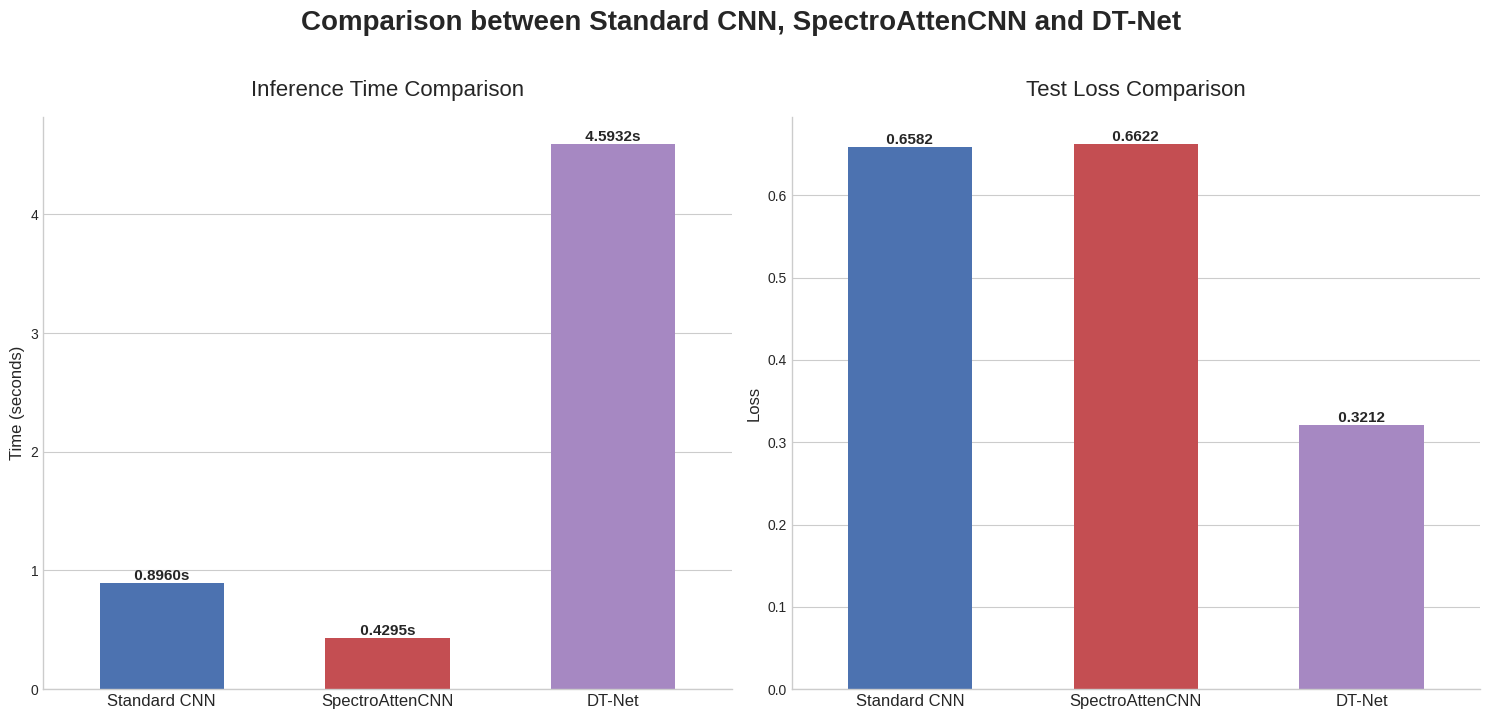

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

#กรองข้อมูลเฉพาะโมเดล CNN และ Attention CNN
cnn_comparison_df = summary_df.loc[['Standard CNN', 'SpectroAttenCNN', 'DT-Net']]

#สร้างกราฟเปรียบเทียบ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Comparison between Standard CNN, SpectroAttenCNN and DT-Net ', fontsize=20, weight='bold', y=1.02)

colors = ['#4C72B0', '#C44E52', '#A688C2']

#กราฟที่ 1: เปรียบเทียบ Inference Time
cnn_comparison_df['Inference Time (s)'].plot(kind='bar', ax=ax1, color=colors, width=0.55)
ax1.set_title('Inference Time Comparison', fontsize=16, pad=15)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_xlabel('') # ไม่ต้องแสดงชื่อแกน X
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.grid(axis='x', visible=False) # เอาเส้นกริดแนวตั้งออก
ax1.spines[['top', 'right']].set_visible(False) # เอากรอบด้านบนและขวาออก

#เพิ่มตัวเลขกำกับแท่งกราฟ และปรับระยะห่าง
for index, value in enumerate(cnn_comparison_df['Inference Time (s)']):
    ax1.text(index, value, f' {value:.4f}s ', ha='center', va='bottom', fontsize=11, weight='bold')

#กราฟที่ 2: เปรียบเทียบ Test Loss
cnn_comparison_df['Test Loss'].plot(kind='bar', ax=ax2, color=colors, width=0.55)
ax2.set_title('Test Loss Comparison', fontsize=16, pad=15)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0, labelsize=12)
ax2.grid(axis='x', visible=False)
ax2.spines[['top', 'right']].set_visible(False)

#เพิ่มตัวเลขกำกับแท่งกราฟ และปรับระยะห่าง
for index, value in enumerate(cnn_comparison_df['Test Loss']):
    ax2.text(index, value, f' {value:.4f} ', ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

DT-Net: พารามิเตอร์ เยอะกระจายอยู่ตาม Layersและต้องใช้เวลาผ่านกระบวนการที่ซับซ้อนหลายสิบขั้นตอน 50 layers กว่าจะเสร็จ จึงช้า ถึงแม้จะ Trainable Params น้อยกว่า

SpectroAttenCNN : มี 3 conv blocks ที่ง่ายและเร็ว พอสุดก็เอาชิ้นส่วนทั้งหมดมาประกอบร่างในขั้นตอนสุดท้าย big dense layer ทำให้เร็วกว่ามาก

ประมาณว่า DT-Net มีตึก 50 ชั้น SpectroAttenCNN มี ตึก 3 ชั้น  ซึ่งโมเดลที่ตื้นกว่ามักจะเร็วกว่าโมเดลที่ลึกกว่า

# Try Real Data
ใช้ DT-Net ในการทำนาย
***เป็นการสาธิตทางเทคนิคเท่านั้น ผลลัพธ์ที่ได้ไม่ใช่การวินิจฉัยทางการแพทย์***

## Dementia
https://youtu.be/iJJerSu8DxE?t=81 Mom, Alzheimers, and a Conversation

In [ ]:
!pip install yt-dlp -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 62.2 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import librosa
from scipy.signal import butter, lfilter
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# *1:21-1:28" ระยะเวลา
!yt-dlp -x --audio-format wav -o "test_video_from_user2.wav" --download-sections "*1:21-1:28" https://www.youtube.com/watch?v=iJJerSu8DxE

print("\nดาวน์โหลดและตัดไฟล์เสียง 'test_video_from_user2.wav' เรียบร้อยแล้ว")

[youtube] Extracting URL: https://www.youtube.com/watch?v=iJJerSu8DxE
[youtube] iJJerSu8DxE: Downloading webpage
[youtube] iJJerSu8DxE: Downloading tv client config
[youtube] iJJerSu8DxE: Downloading player 761c1f12-main
[youtube] iJJerSu8DxE: Downloading tv player API JSON
[youtube] iJJerSu8DxE: Downloading ios player API JSON
[youtube] iJJerSu8DxE: Downloading m3u8 information
[info] iJJerSu8DxE: Downloading 1 format(s): 251
[info] iJJerSu8DxE: Downloading 1 time ranges: 81.0-88.0
[download] Destination: test_video_from_user2.webm
Input #0, matroska,webm, from 'https://rr4---sn-q4fzen7s.googlevideo.com/videoplayback?expire=1754766976&ei=IEqXaM3SK7qpsfIP852NsQo&ip=34.125.113.86&id=o-ADgf-yjXWmAsqF4DfnlZvVpBKPn8wo5GNGNaeKlmuRDT&itag=251&source=youtube&requiressl=yes&xpc=EgVo2aDSNQ%3D%3D&met=1754745376%2C&mh=wb&mm=31%2C26&mn=sn-q4fzen7s%2Csn-a5mekn6r&ms=au%2Conr&mv=u&mvi=4&pl=20&rms=au%2Cau&bui=AY1jyLMwd6IFxL-bRTgK8CrDuD4M4gLxSGX6frWMIiI5cSji8gfo3FMncmOkywctvIERdabYU5ncQIxr&vprv=1&svpuc

In [ ]:
# คัดลอกฟังก์ชัน Preprocessing ที่จำเป็น
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(y, sr, lowcut=80, highcut=8000):
    b, a = butter_bandpass(lowcut, highcut, sr, order=5)
    return lfilter(b, a, y)

def extract_mel_spectrograms(y, sr, segment_length_sec=10, hop_length_sec=5, n_mels=128):
    segment_samples, hop_samples = segment_length_sec * sr, hop_length_sec * sr
    spectrograms = []
    if len(y) < segment_samples:
        y = np.pad(y, (0, segment_samples - len(y)), mode='constant')
    for i in range(0, len(y) - segment_samples + 1, hop_samples):
        segment = y[i:i + segment_samples]
        mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=n_mels)
        spectrograms.append(librosa.power_to_db(mel_spec, ref=np.max))
    return spectrograms

#ชื่อไฟล์โมเดลและไฟล์เสียง
MODEL_FILE = '/content/best_resnet_model.keras'
AUDIO_FILE = '/content/test_video_from_user2.wav'
SR = 22050

try:
    # 1. โหลดโมเดล
    print(f"กำลังโหลดโมเดลจากไฟล์: {MODEL_FILE}")
    # ใช้ compile=False เพื่อความเร็วในการโหลด เพราะไม่ต้องการฝึกซ้ำ
    model = tf.keras.models.load_model(MODEL_FILE, compile=False)

    # 2. โหลดและประมวลผลไฟล์เสียง
    print(f"กำลังประมวลผลไฟล์เสียง: {AUDIO_FILE}")
    audio, sr = librosa.load(AUDIO_FILE, sr=SR)
    filtered_audio = apply_bandpass_filter(audio, sr)

    # 3. สร้าง Spectrogram segments
    spectrogram_segments = extract_mel_spectrograms(filtered_audio, sr)
    if not spectrogram_segments:
        print("ไม่สามารถสร้าง Spectrogram segments จากไฟล์เสียงได้ อาจจะสั้นเกินไป")
    else:
        # แปลงเป็น NumPy array และเพิ่ม Dimension สำหรับโมเดล
        X_predict = np.array(spectrogram_segments)[..., np.newaxis]
        print(f"ไฟล์เสียงถูกแบ่งออกเป็น {len(X_predict)} segments เพื่อทำนายผล")

        # 4. ทำนายผล
        predictions = model.predict(X_predict)

        # 5. สรุปผลการทำนาย
        predicted_classes = (predictions > 0.5).astype("int32").flatten()
        average_probability = np.mean(predictions)
        dementia_votes = np.sum(predicted_classes)
        nodementia_votes = len(predicted_classes) - dementia_votes

        print("\nผลการทำนาย ")
        print(f"ค่าความน่าจะเป็นเฉลี่ย (Dementia): {average_probability:.4f}")
        print(f"ผลโหวต: No Dementia [{nodementia_votes} segments] vs Dementia [{dementia_votes} segments]")

        # ตัดสินผลลัพธ์สุดท้าย
        final_prediction = "Dementia" if average_probability > 0.5 else "No Dementia"
        print(f"\n>> ผลการทำนายสุดท้ายสำหรับคลิปนี้คือ: {final_prediction}")

except Exception as e:
    print(f"\nเกิดข้อผิดพลาด: {e}")
    print(f"โปรดตรวจสอบว่าไฟล์ '{MODEL_FILE}' อยู่ในตำแหน่งที่ถูกต้องและเป็นไฟล์โมเดลที่สมบูรณ์")

กำลังโหลดโมเดลจากไฟล์: /content/best_resnet_model.keras
กำลังประมวลผลไฟล์เสียง: /content/test_video_from_user2.wav
ไฟล์เสียงถูกแบ่งออกเป็น 1 segments เพื่อทำนายผล
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

ผลการทำนาย 
ค่าความน่าจะเป็นเฉลี่ย (Dementia): 0.8465
ผลโหวต: No Dementia [0 segments] vs Dementia [1 segments]

>> ผลการทำนายสุดท้ายสำหรับคลิปนี้คือ: Dementia


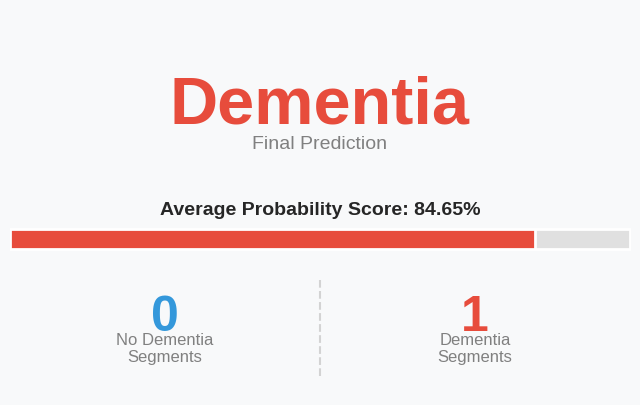

In [ ]:
import matplotlib.pyplot as plt

# ข้อมูลผลลัพธ์จากการทำนาย
average_probability = 0.8465

nodementia_votes = 0
dementia_votes = 1
final_prediction = "Dementia"

# สร้างภาพสำหรับแสดงผล
# กำหนด Style และขนาดของภาพ
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
fig.patch.set_facecolor('#f8f9fa') # สีพื้นหลัง

# แสดงผลการทำนายหลัก
result_color = '#e74c3c' # สีแดงสำหรับ 'Dementia'
ax.text(0.5, 0.75, final_prediction,
        ha='center', va='center',
        fontsize=48, weight='bold', color=result_color)
ax.text(0.5, 0.65, 'Final Prediction',
        ha='center', va='center',
        fontsize=14, color='gray')

# แสดงแถบค่าความน่าจะเป็นเฉลี่ย (Confidence Bar)
ax.text(0.5, 0.48, f'Average Probability Score: {average_probability:.2%}',
        ha='center', va='center',
        fontsize=14, weight='bold')

# สร้างแถบพื้นหลังสีเทา
ax.broken_barh([(0, 1)], (0.38, 0.05), facecolors='#e0e0e0', edgecolor='white', linewidth=2)
# สร้างแถบแสดงค่าความน่าจะเป็น
ax.broken_barh([(0, average_probability)], (0.38, 0.05), facecolors=result_color, edgecolor='white', linewidth=2)


#  แสดงผลโหวต (Segment Vote Breakdown)
ax.axvline(0.5, ymin=0.05, ymax=0.3, color='lightgray', linestyle='--') # เส้นแบ่งกลาง

# ผลโหวต No Dementia
no_dementia_color = '#3498db'
ax.text(0.25, 0.20, f'{nodementia_votes}',
        ha='center', va='center',
        fontsize=36, weight='bold', color=no_dementia_color)
ax.text(0.25, 0.12, 'No Dementia\nSegments',
        ha='center', va='center',
        fontsize=12, color='gray')

# ผลโหวต Dementia
ax.text(0.75, 0.20, f'{dementia_votes}',
        ha='center', va='center',
        fontsize=36, weight='bold', color=result_color)
ax.text(0.75, 0.12, 'Dementia\nSegments',
        ha='center', va='center',
        fontsize=12, color='gray')


# ปรับแต่งการแสดงผลสุดท้าย
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off') # ซ่อนแกน X, Y
plt.show()

##No Dementia
https://youtu.be/NcaQUH2K-wo?t=931 Simon Sinek: The Advice Young People NEED To Hear | E176

In [ ]:
# *15:31-15:38" ระยะเวลา
!yt-dlp -x --audio-format wav -o "test_video_from_user1.wav" --download-sections "*15:31-15:38" https://www.youtube.com/watch?v=NcaQUH2K-wo
print("\nดาวน์โหลดและตัดไฟล์เสียง 'test_video_from_user1.wav' เรียบร้อยแล้ว")

[youtube] Extracting URL: https://www.youtube.com/watch?v=NcaQUH2K-wo
[youtube] NcaQUH2K-wo: Downloading webpage
[youtube] NcaQUH2K-wo: Downloading tv client config
[youtube] NcaQUH2K-wo: Downloading tv player API JSON
[youtube] NcaQUH2K-wo: Downloading ios player API JSON
[youtube] NcaQUH2K-wo: Downloading m3u8 information
[info] Testing format 234
[info] NcaQUH2K-wo: Downloading 1 format(s): 234
[info] NcaQUH2K-wo: Downloading 1 time ranges: 931.0-938.0
[download] Destination: test_video_from_user1.mp4
[hls @ 0x5ad6dd4fe140] Skip ('#EXT-X-VERSION:3')
[hls @ 0x5ad6dd4fe140] Opening 'https://rr4---sn-q4flrnee.googlevideo.com/videoplayback/id/35c690507d8afb0a/itag/234/source/youtube/expire/1754767663/ei/z0yXaNGFHY3EsfIP4sjiiAQ/ip/34.125.113.86/requiressl/yes/ratebypass/yes/pfa/1/goi/133/sgoap/clen%3D102022591%3Bdur%3D6303.892%3Bgir%3Dyes%3Bitag%3D140%3Blmt%3D1736856551655766/rqh/1/hls_chunk_host/rr4---sn-q4flrnee.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/cps/58/met/1754746063,/mh/7_/mm/31,29

In [ ]:
# คัดลอกฟังก์ชัน Preprocessing ที่จำเป็น
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(y, sr, lowcut=80, highcut=8000):
    b, a = butter_bandpass(lowcut, highcut, sr, order=5)
    return lfilter(b, a, y)

def extract_mel_spectrograms(y, sr, segment_length_sec=10, hop_length_sec=5, n_mels=128):
    segment_samples, hop_samples = segment_length_sec * sr, hop_length_sec * sr
    spectrograms = []
    if len(y) < segment_samples:
        y = np.pad(y, (0, segment_samples - len(y)), mode='constant')
    for i in range(0, len(y) - segment_samples + 1, hop_samples):
        segment = y[i:i + segment_samples]
        mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=n_mels)
        spectrograms.append(librosa.power_to_db(mel_spec, ref=np.max))
    return spectrograms

#ชื่อไฟล์โมเดลและไฟล์เสียง
MODEL_FILE = '/content/best_resnet_model.keras'
AUDIO_FILE = '/content/test_video_from_user1.wav'
SR = 22050

try:
    # 1. โหลดโมเดล
    print(f"กำลังโหลดโมเดลจากไฟล์: {MODEL_FILE}")
    # ใช้ compile=False เพื่อความเร็วในการโหลด เพราะไม่ต้องการฝึกซ้ำ
    model = tf.keras.models.load_model(MODEL_FILE, compile=False)

    # 2. โหลดและประมวลผลไฟล์เสียง
    print(f"กำลังประมวลผลไฟล์เสียง: {AUDIO_FILE}")
    audio, sr = librosa.load(AUDIO_FILE, sr=SR)
    filtered_audio = apply_bandpass_filter(audio, sr)

    # 3. สร้าง Spectrogram segments
    spectrogram_segments = extract_mel_spectrograms(filtered_audio, sr)
    if not spectrogram_segments:
        print("ไม่สามารถสร้าง Spectrogram segments จากไฟล์เสียงได้ อาจจะสั้นเกินไป")
    else:
        # แปลงเป็น NumPy array และเพิ่ม Dimension สำหรับโมเดล
        X_predict = np.array(spectrogram_segments)[..., np.newaxis]
        print(f"ไฟล์เสียงถูกแบ่งออกเป็น {len(X_predict)} segments เพื่อทำนายผล")

        # 4. ทำนายผล
        predictions = model.predict(X_predict)

        # 5. สรุปผลการทำนาย
        predicted_classes = (predictions > 0.5).astype("int32").flatten()
        average_probability = np.mean(predictions)
        dementia_votes = np.sum(predicted_classes)
        nodementia_votes = len(predicted_classes) - dementia_votes

        print("\nผลการทำนาย ")
        print(f"ค่าความน่าจะเป็นเฉลี่ย (Dementia): {average_probability:.4f}")
        print(f"ผลโหวต: No Dementia [{nodementia_votes} segments] vs Dementia [{dementia_votes} segments]")

        # ตัดสินผลลัพธ์สุดท้าย
        final_prediction = "Dementia" if average_probability > 0.5 else "No Dementia"
        print(f"\n>> ผลการทำนายสุดท้ายสำหรับคลิปนี้คือ: {final_prediction}")

except Exception as e:
    print(f"\nเกิดข้อผิดพลาด: {e}")
    print(f"โปรดตรวจสอบว่าไฟล์ '{MODEL_FILE}' อยู่ในตำแหน่งที่ถูกต้องและเป็นไฟล์โมเดลที่สมบูรณ์")

กำลังโหลดโมเดลจากไฟล์: /content/best_resnet_model.keras
กำลังประมวลผลไฟล์เสียง: /content/test_video_from_user1.wav
ไฟล์เสียงถูกแบ่งออกเป็น 1 segments เพื่อทำนายผล
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

ผลการทำนาย 
ค่าความน่าจะเป็นเฉลี่ย (Dementia): 0.2088
ผลโหวต: No Dementia [1 segments] vs Dementia [0 segments]

>> ผลการทำนายสุดท้ายสำหรับคลิปนี้คือ: No Dementia


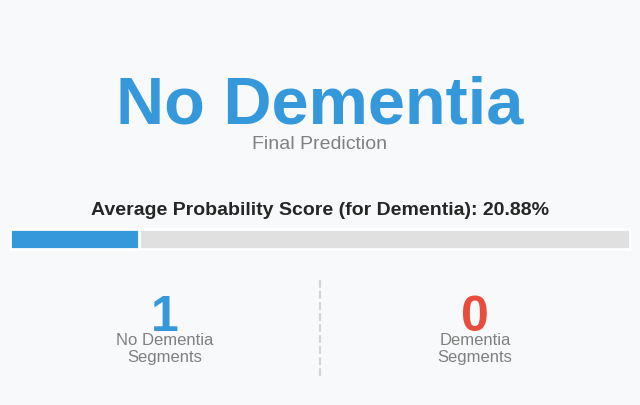

In [ ]:
# ข้อมูลผลลัพธ์จากการทำนาย
average_probability = 0.2088
nodementia_votes = 1
dementia_votes = 0
final_prediction = "No Dementia"

# สร้างภาพสำหรับแสดงผล
# กำหนด Style และขนาดของภาพ
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
fig.patch.set_facecolor('#f8f9fa') # สีพื้นหลัง

# แสดงผลการทำนายหลัก
result_color = '#3498db' # สีน้ำเงินสำหรับ 'No Dementia'
ax.text(0.5, 0.75, final_prediction,
        ha='center', va='center',
        fontsize=48, weight='bold', color=result_color)
ax.text(0.5, 0.65, 'Final Prediction',
        ha='center', va='center',
        fontsize=14, color='gray')

# แสดงแถบค่าความน่าจะเป็นเฉลี่ย (Confidence Bar)
ax.text(0.5, 0.48, f'Average Probability Score (for Dementia): {average_probability:.2%}',
        ha='center', va='center',
        fontsize=14, weight='bold')

# สร้างแถบพื้นหลังสีเทา
ax.broken_barh([(0, 1)], (0.38, 0.05), facecolors='#e0e0e0', edgecolor='white', linewidth=2)
# สร้างแถบแสดงค่าความน่าจะเป็น (จะเป็นสีแดง หากค่าสูง)
dementia_color_bar = '#3498db'
ax.broken_barh([(0, average_probability)], (0.38, 0.05), facecolors=dementia_color_bar, edgecolor='white', linewidth=2)


# แสดงผลโหวต (Segment Vote Breakdown)
ax.axvline(0.5, ymin=0.05, ymax=0.3, color='lightgray', linestyle='--') # เส้นแบ่งกลาง

# ผลโหวต No Dementia
ax.text(0.25, 0.20, f'{nodementia_votes}',
        ha='center', va='center',
        fontsize=36, weight='bold', color=result_color)
ax.text(0.25, 0.12, 'No Dementia\nSegments',
        ha='center', va='center',
        fontsize=12, color='gray')

# ผลโหวต Dementia
dementia_color_text = '#e74c3c'
ax.text(0.75, 0.20, f'{dementia_votes}',
        ha='center', va='center',
        fontsize=36, weight='bold', color=dementia_color_text)
ax.text(0.75, 0.12, 'Dementia\nSegments',
        ha='center', va='center',
        fontsize=12, color='gray')


# ปรับแต่งการแสดงผลสุดท้าย
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off') # ซ่อนแกน X, Y
plt.show()

https://youtu.be/FjrJ2DJN_pA?t=2676 MrBeast: If You Want To Be Liked, Don't Help People & I Lost Tens Of Millions On Beast Games!

In [ ]:
# *44:36-45:43" เสียงยาว
!yt-dlp -x --audio-format wav -o "test_video_from_user.wav" --download-sections "*44:36-45:43" https://www.youtube.com/watch?v=NcaQUH2K-wo
print("\nดาวน์โหลดและตัดไฟล์เสียง 'test_video_from_user.wav' เรียบร้อยแล้ว")

[youtube] Extracting URL: https://www.youtube.com/watch?v=NcaQUH2K-wo
[youtube] NcaQUH2K-wo: Downloading webpage
[youtube] NcaQUH2K-wo: Downloading tv client config
[youtube] NcaQUH2K-wo: Downloading tv player API JSON
[youtube] NcaQUH2K-wo: Downloading ios player API JSON
[youtube] NcaQUH2K-wo: Downloading m3u8 information
[info] Testing format 234
[info] NcaQUH2K-wo: Downloading 1 format(s): 234
[info] NcaQUH2K-wo: Downloading 1 time ranges: 2676.0-2743.0
[download] Destination: test_video_from_user.mp4
[hls @ 0x5d28ff9b3140] Skip ('#EXT-X-VERSION:3')
[hls @ 0x5d28ff9b3140] Opening 'https://rr4---sn-q4flrnee.googlevideo.com/videoplayback/id/35c690507d8afb0a/itag/234/source/youtube/expire/1754767810/ei/Yk2XaJXhHLOQsfIPwpKLgQE/ip/34.125.113.86/requiressl/yes/ratebypass/yes/pfa/1/goi/133/sgoap/clen%3D102022591%3Bdur%3D6303.892%3Bgir%3Dyes%3Bitag%3D140%3Blmt%3D1736856551655766/rqh/1/hls_chunk_host/rr4---sn-q4flrnee.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/cps/10/met/1754746210,/mh/7_/mm/31,2

In [ ]:
# คัดลอกฟังก์ชัน Preprocessing ที่จำเป็น
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(y, sr, lowcut=80, highcut=8000):
    b, a = butter_bandpass(lowcut, highcut, sr, order=5)
    return lfilter(b, a, y)

def extract_mel_spectrograms(y, sr, segment_length_sec=10, hop_length_sec=5, n_mels=128):
    segment_samples, hop_samples = segment_length_sec * sr, hop_length_sec * sr
    spectrograms = []
    if len(y) < segment_samples:
        y = np.pad(y, (0, segment_samples - len(y)), mode='constant')
    for i in range(0, len(y) - segment_samples + 1, hop_samples):
        segment = y[i:i + segment_samples]
        mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=n_mels)
        spectrograms.append(librosa.power_to_db(mel_spec, ref=np.max))
    return spectrograms

#ชื่อไฟล์โมเดลและไฟล์เสียง
MODEL_FILE = '/content/best_resnet_model.keras'
AUDIO_FILE = '/content/test_video_from_user.wav'
SR = 22050

try:
    # 1. โหลดโมเดล
    print(f"กำลังโหลดโมเดลจากไฟล์: {MODEL_FILE}")
    # ใช้ compile=False เพื่อความเร็วในการโหลด เพราะไม่ต้องการฝึกซ้ำ
    model = tf.keras.models.load_model(MODEL_FILE, compile=False)

    # 2. โหลดและประมวลผลไฟล์เสียง
    print(f"กำลังประมวลผลไฟล์เสียง: {AUDIO_FILE}")
    audio, sr = librosa.load(AUDIO_FILE, sr=SR)
    filtered_audio = apply_bandpass_filter(audio, sr)

    # 3. สร้าง Spectrogram segments
    spectrogram_segments = extract_mel_spectrograms(filtered_audio, sr)
    if not spectrogram_segments:
        print("ไม่สามารถสร้าง Spectrogram segments จากไฟล์เสียงได้ อาจจะสั้นเกินไป")
    else:
        # แปลงเป็น NumPy array และเพิ่ม Dimension สำหรับโมเดล
        X_predict = np.array(spectrogram_segments)[..., np.newaxis]
        print(f"ไฟล์เสียงถูกแบ่งออกเป็น {len(X_predict)} segments เพื่อทำนายผล")

        # 4. ทำนายผล
        predictions = model.predict(X_predict)

        # 5. สรุปผลการทำนาย
        predicted_classes = (predictions > 0.5).astype("int32").flatten()
        average_probability = np.mean(predictions)
        dementia_votes = np.sum(predicted_classes)
        nodementia_votes = len(predicted_classes) - dementia_votes

        print("\nผลการทำนาย ")
        print(f"ค่าความน่าจะเป็นเฉลี่ย (Dementia): {average_probability:.4f}")
        print(f"ผลโหวต: No Dementia [{nodementia_votes} segments] vs Dementia [{dementia_votes} segments]")

        # ตัดสินผลลัพธ์สุดท้าย
        final_prediction = "Dementia" if average_probability > 0.5 else "No Dementia"
        print(f"\n>> ผลการทำนายสุดท้ายสำหรับคลิปนี้คือ: {final_prediction}")

except Exception as e:
    print(f"\nเกิดข้อผิดพลาด: {e}")
    print(f"โปรดตรวจสอบว่าไฟล์ '{MODEL_FILE}' อยู่ในตำแหน่งที่ถูกต้องและเป็นไฟล์โมเดลที่สมบูรณ์")

กำลังโหลดโมเดลจากไฟล์: /content/best_resnet_model.keras
กำลังประมวลผลไฟล์เสียง: /content/test_video_from_user.wav
ไฟล์เสียงถูกแบ่งออกเป็น 12 segments เพื่อทำนายผล
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

ผลการทำนาย 
ค่าความน่าจะเป็นเฉลี่ย (Dementia): 0.3921
ผลโหวต: No Dementia [8 segments] vs Dementia [4 segments]

>> ผลการทำนายสุดท้ายสำหรับคลิปนี้คือ: No Dementia


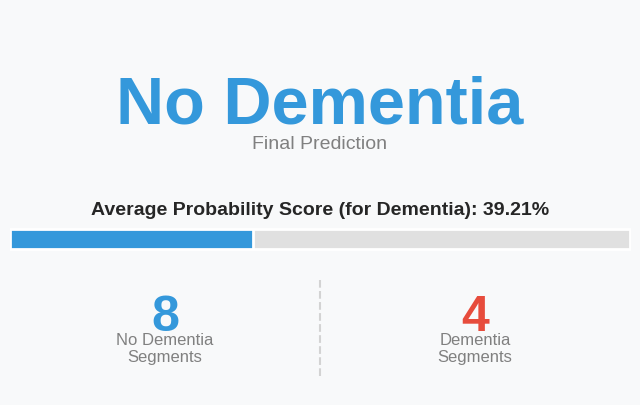

In [ ]:
import matplotlib.pyplot as plt

# ข้อมูลผลลัพธ์จากการทำนาย
average_probability = 0.3921
nodementia_votes = 8
dementia_votes = 4
final_prediction = "No Dementia"

#  สร้างภาพสำหรับแสดงผล
# กำหนด Style และขนาดของภาพ
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
fig.patch.set_facecolor('#f8f9fa') # สีพื้นหลัง

#  แสดงผลการทำนายหลัก
result_color = '#3498db' # สีน้ำเงินสำหรับ 'No Dementia'
ax.text(0.5, 0.75, final_prediction,
        ha='center', va='center',
        fontsize=48, weight='bold', color=result_color)
ax.text(0.5, 0.65, 'Final Prediction',
        ha='center', va='center',
        fontsize=14, color='gray')

#  แสดงแถบค่าความน่าจะเป็นเฉลี่ย (Confidence Bar)
ax.text(0.5, 0.48, f'Average Probability Score (for Dementia): {average_probability:.2%}',
        ha='center', va='center',
        fontsize=14, weight='bold')

# สร้างแถบพื้นหลังสีเทา
ax.broken_barh([(0, 1)], (0.38, 0.05), facecolors='#e0e0e0', edgecolor='white', linewidth=2)
# สร้างแถบแสดงค่าความน่าจะเป็น (จะเป็นสีแดง หากค่าสูง)
dementia_color_bar = '#3498db'
ax.broken_barh([(0, average_probability)], (0.38, 0.05), facecolors=dementia_color_bar, edgecolor='white', linewidth=2)


# แสดงผลโหวต (Segment Vote Breakdown)
ax.axvline(0.5, ymin=0.05, ymax=0.3, color='lightgray', linestyle='--') # เส้นแบ่งกลาง

# ผลโหวต No Dementia
ax.text(0.25, 0.20, f'{nodementia_votes}',
        ha='center', va='center',
        fontsize=36, weight='bold', color=result_color)
ax.text(0.25, 0.12, 'No Dementia\nSegments',
        ha='center', va='center',
        fontsize=12, color='gray')

# ผลโหวต Dementia
dementia_color_text = '#e74c3c'
ax.text(0.75, 0.20, f'{dementia_votes}',
        ha='center', va='center',
        fontsize=36, weight='bold', color=dementia_color_text)
ax.text(0.75, 0.12, 'Dementia\nSegments',
        ha='center', va='center',
        fontsize=12, color='gray')


#  ปรับแต่งการแสดงผลสุดท้าย
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off') # ซ่อนแกน X, Y
plt.show()